In [1]:
import numpy
print(numpy.__file__)
import pandas as pd
import torch
import torch.nn as nn
import sys
import os

from AIedes.models.counter_models import (
    PositiveFeedForwardAbundanceModel,
    PositiveLSTMAbundanceModel,
    PositiveMultiHeadAttentionModel,
    PositiveHurdleModel
)
from AIedes.train.counter_train import train_mosquito_net

from AIedes.data_loader.counter_data_loader import (
    load_and_process_data,
    prepare_data,
)

from AIedes.utils.counter_losses import get_criterion



/home/biazzin/conda-envs/pytorch/lib/python3.11/site-packages/numpy/__init__.py


In [2]:
random_state = 3
dropout_rate = 0.2
layers = 2
hidden_size = 64
bs = 64
learning_rate = "5e-05"  # From your data (appears to be consistent)

input_variables = "t2m_mean_znorm+tp_sum_znorm+d2m_mean_znorm+p1zn+p2zn"
#input_variables = "t2m_mean_norm+prev2_weeklyRates_norm+prev_weeklyRates_norm+tp_sum_norm+d2m_mean_norm"
name_file = f"modelpositive_ff_lossFrequencyWeighted_hid{hidden_size}_lay{layers}_do{dropout_rate}_lr{learning_rate}_bs{bs}_sd{random_state}_{input_variables}"
#name_file = "modelpositive_ff_lossFrequencyWeighted_hid16_lay3_do0.2_lr1e-04_bs32_sd2_t2m_mean_norm+prev2_weeklyRates_norm+prev_weeklyRates_norm+tp_sum_norm+d2m_mean_norm"
path = "../MSE/"
df = pd.read_pickle(path + name_file + "_results.pkl")
model = torch.load(path+name_file + ".pth", map_location=torch.device('cpu'), weights_only=False)

In [3]:

from sklearn.model_selection import train_test_split
import  numpy as np

params = {
    "model_type": df["model_type"][0],  # or any of the allowed models
    "hidden_dim": df["hidden_dim"][0],
    "num_layers": df["num_layers"][0],
    "dropout": df["dropout"][0],
    "num_epochs": df["num_epochs"][0],
    "lr": df["learning_rate"][0],
    "batch_size": int(df["batch_size"][0]),
    "random_state": int(df["random_state"][0]),
    "num_threads": 1,
    #"variables": ["t2m:mean,max:30", "tp:mean,max:30"],
    "variables":   "t2m_mean_znorm tp_sum_znorm d2m_mean_znorm p1zn p2zn".split(),
    "loss_type": df["loss_type"][0],  # or another from the list
    # "nonzero_weight": 3.0,  # Uncomment if used
    "num_heads": 4,
    "folder_res": "./results/",
    "device": "cpu",  # or "cpu"
    "input_file": "../../data/eggs_y_norm_7days.pkl",
    "save_loss_fig": "yes",  # or "no"
    "plot_loss": False,
    "save_interval": 10,
    "bins": [1],  # Or [0, 10, 50, 200] if you want bins
}

climate_tensor, targets, class_labels, variable_info = load_and_process_data(params)

all_idx = np.arange(len(climate_tensor))
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=params["random_state"],
    stratify=class_labels if class_labels is not None else None,
)

# And later:
data_egg = pd.read_pickle(params["input_file"])  # Or however you got your original dataframe

# To recover rows:
split_status = np.full(len(all_idx), "", dtype=object)
split_status[train_idx] = "train"
split_status[test_idx] = "test"
data_egg["split"] = split_status
# If climate_tensor and targets are numpy arrays, convert each row to torch.tensor
data_egg["input_data"] = [torch.tensor(x, dtype=torch.float32) for x in climate_tensor]
data_egg["target_data"] = [np.array(x, dtype=np.float32)[0] for x in targets]


Normalizing data...
Normalized 34 fields: ['tp_sum', 'u10_min', 'u10_max', 'u10_mean', 'v10_min', 'v10_max', 'v10_mean', 'd2m_min', 'd2m_max', 'd2m_mean', 't2m_min', 't2m_max', 't2m_mean', 'swvl1_min', 'swvl1_max', 'swvl1_mean', 'tp_sum_monthly', 'u10_min_monthly', 'u10_max_monthly', 'u10_mean_monthly', 'v10_min_monthly', 'v10_max_monthly', 'v10_mean_monthly', 'd2m_min_monthly', 'd2m_max_monthly', 'd2m_mean_monthly', 't2m_min_monthly', 't2m_max_monthly', 't2m_mean_monthly', 'swvl1_min_monthly', 'swvl1_max_monthly', 'swvl1_mean_monthly', 'prev1_rates', 'prev2_rates']


In [4]:

params_vectorNet = {
    "model_type": df["model_type"][0],  # or any of the allowed models
    "hidden_dim": df["hidden_dim"][0],
    "num_layers": df["num_layers"][0],
    "dropout": df["dropout"][0],
    "num_epochs": df["num_epochs"][0],
    "lr": df["learning_rate"][0],
    "batch_size": int(df["batch_size"][0]),
    "random_state": int(df["random_state"][0]),
    "num_threads": 1,
    #"variables": ["t2m:mean,max:30", "tp:mean,max:30"],
    "variables":   "t2m_mean_znorm tp_sum_znorm d2m_mean_znorm p1zn p2zn".split(),
    "loss_type": df["loss_type"][0],  # or another from the list
    # "nonzero_weight": 3.0,  # Uncomment if used
    "num_heads": 4,
    "folder_res": "./results/",
    "device": "cpu",  # or "cpu"
    "input_file": "../../data/eggs_y_norm_7days_vectorNet.pkl",
    "save_loss_fig": "yes",  # or "no"
    "plot_loss": False,
    "save_interval": 10,
    "bins": [1],  # Or [0, 10, 50, 200] if you want bins
}

climate_tensor_vectorNet, targets_vectorNet, class_labels_vectorNet, variable_info_vectorNet = load_and_process_data(params_vectorNet)
all_idx_vectorNet = np.arange(len(climate_tensor_vectorNet))
train_idx_vectorNet, test_idx_vectorNet = train_test_split(
    all_idx_vectorNet,
    test_size=0.2,
    random_state=params_vectorNet["random_state"],
    stratify=class_labels_vectorNet if class_labels_vectorNet is not None else None,
)
data_egg_vectorNet = pd.read_pickle(params_vectorNet["input_file"])  # Or however you got your original dataframe
# To recover rows:
split_status_vectorNet = np.full(len(all_idx_vectorNet), "", dtype=object)
split_status_vectorNet[train_idx_vectorNet] = "train"
split_status_vectorNet[test_idx_vectorNet] = "test"
data_egg_vectorNet["split"] = split_status_vectorNet
# If climate_tensor and targets are numpy arrays, convert each row to torch.tensor
data_egg_vectorNet["input_data"] = [torch.tensor(x, dtype=torch.float32) for x in climate_tensor_vectorNet]
data_egg_vectorNet["target_data"] = [np.array(x, dtype=np.float32)[0] for x in targets_vectorNet]


Normalizing data...
Normalized 16 fields: ['tp_sum', 'd2m_min', 'd2m_max', 'd2m_mean', 't2m_min', 't2m_max', 't2m_mean', 'tp_sum_monthly', 'd2m_min_monthly', 'd2m_max_monthly', 'd2m_mean_monthly', 't2m_min_monthly', 't2m_max_monthly', 't2m_mean_monthly', 'prev1_rates', 'prev2_rates']
Skipped 18 fields: ['u10_min (missing)', 'u10_max (missing)', 'u10_mean (missing)', 'v10_min (missing)', 'v10_max (missing)', 'v10_mean (missing)', 'swvl1_min (missing)', 'swvl1_max (missing)', 'swvl1_mean (missing)', 'u10_min_monthly (missing)', 'u10_max_monthly (missing)', 'u10_mean_monthly (missing)', 'v10_min_monthly (missing)', 'v10_max_monthly (missing)', 'v10_mean_monthly (missing)', 'swvl1_min_monthly (missing)', 'swvl1_max_monthly (missing)', 'swvl1_mean_monthly (missing)']


In [5]:
data_egg["class_labels"] = class_labels
data_egg["predictions"] = [model(x.unsqueeze(0)).squeeze(0).detach().numpy()[0] for x in data_egg["input_data"]]
data_egg_vectorNet["class_labels"] = class_labels_vectorNet
data_egg_vectorNet["predictions"] = [model(x.unsqueeze(0)).squeeze(0).detach().numpy()[0] for x in data_egg_vectorNet["input_data"]]

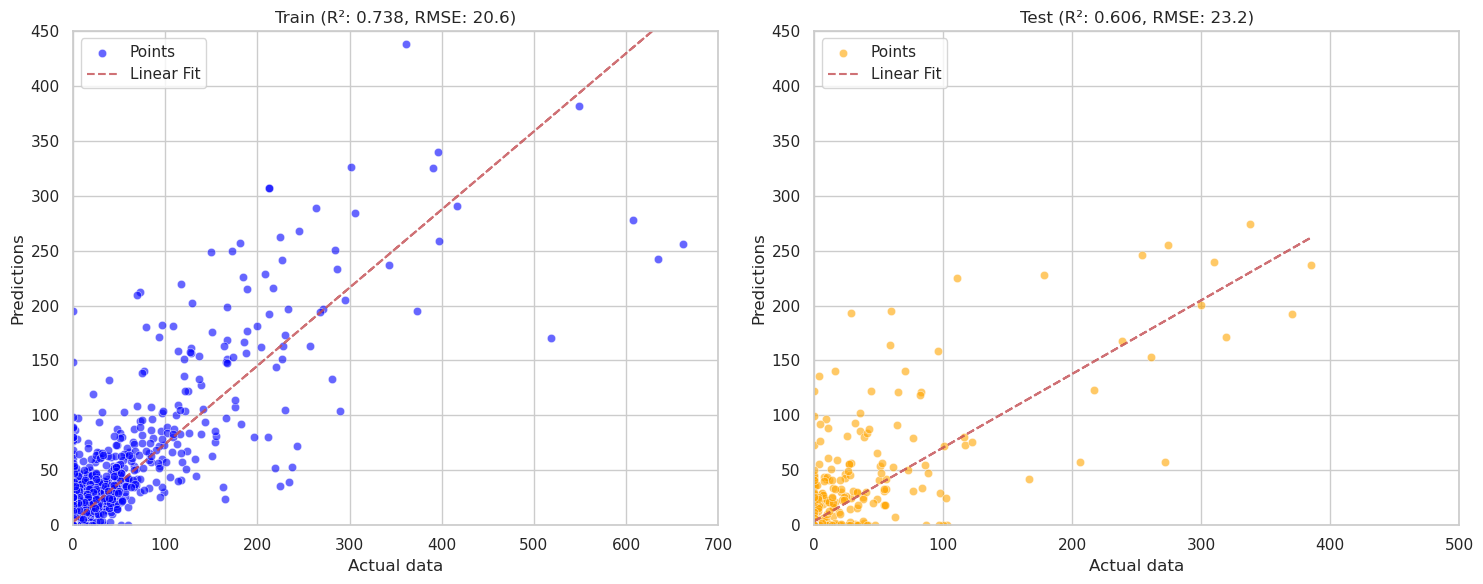

In [6]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
# scatter plot of targets vs predictions with seaborn
sns.set(style="whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test = data_egg[data_egg["split"] == "test"]

# Train plot
sns.scatterplot(x=data_egg_train["target_data"], y=data_egg_train["predictions"], ax=axs[0], color='blue', alpha=0.6)
r2_train = r2_score(data_egg_train["target_data"], data_egg_train["predictions"])
rmse_train = np.sqrt(mean_squared_error(data_egg_train["target_data"], data_egg_train["predictions"]))
# Add linear fit
z_train = np.polyfit(data_egg_train["target_data"], data_egg_train["predictions"], 1)
p_train = np.poly1d(z_train)
axs[0].plot(data_egg_train["target_data"], p_train(data_egg_train["target_data"]), "r--", alpha=0.8)
axs[0].set_title(f'Train (R²: {r2_train:.3f}, RMSE: {rmse_train:.1f})')
axs[0].set_xlabel("Actual data")
axs[0].set_ylabel("Predictions")

# Test plot
sns.scatterplot(x=data_egg_test["target_data"], y=data_egg_test["predictions"], ax=axs[1], color='orange', alpha=0.6)
r2_test = r2_score(data_egg_test["target_data"], data_egg_test["predictions"])
rmse_test = np.sqrt(mean_squared_error(data_egg_test["target_data"], data_egg_test["predictions"]))
# Add linear fit
z_test = np.polyfit(data_egg_test["target_data"], data_egg_test["predictions"], 1)
p_test = np.poly1d(z_test)
axs[1].plot(data_egg_test["target_data"], p_test(data_egg_test["target_data"]), "r--", alpha=0.8)
axs[1].set_title(f'Test (R²: {r2_test:.3f}, RMSE: {rmse_test:.1f})')
axs[1].set_xlabel("Actual data")
axs[1].set_ylabel("Predictions")

# legend
axs[0].legend(['Points', 'Linear Fit'], loc='upper left')
axs[1].legend(['Points', 'Linear Fit'], loc='upper left')

axs[0].set_xlim(0, 700)
axs[0].set_ylim(0, 450)
axs[1].set_xlim(0, 500)
axs[1].set_ylim(0, 450)
#axs[0].plot([0, 700], [0, 700], 'k--', lw=1)  # Diagonal line for reference
#axs[1].plot([0, 700], [0, 700], 'k--', lw=1)  # Diagonal line for reference

plt.tight_layout()
plt.savefig(f"./R2_scatter_plot.pdf")
plt.show()

Optimal Box-Cox lambda: -1.5192041927416629


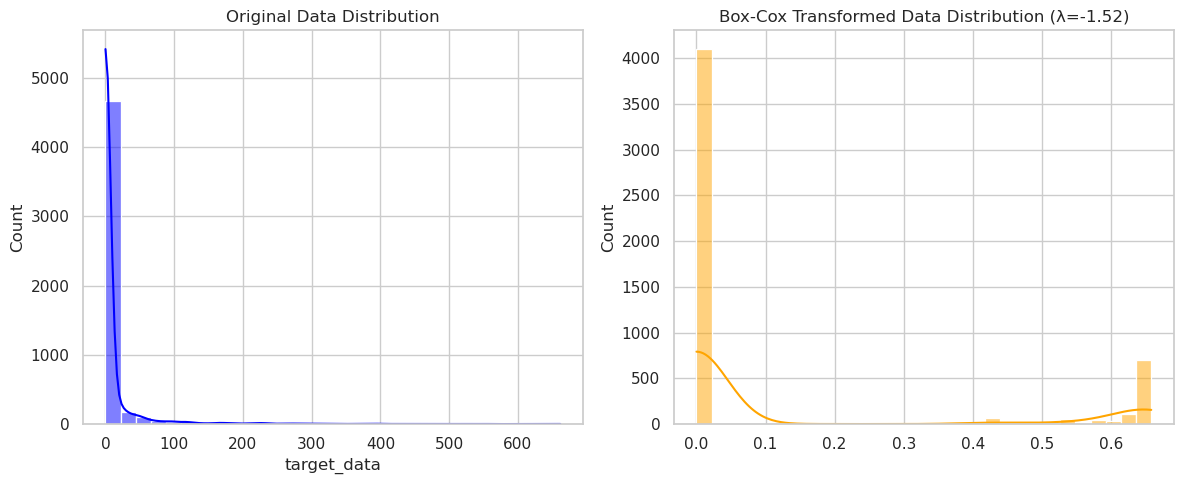

In [ ]:
# compute the cox box value lambda
import scipy.stats as stats
data_egg_plus_one = data_egg["target_data"] + 1

# Compute Box-Cox transform and the best lambda
y_transformed, lambda_opt = stats.boxcox(data_egg_plus_one)
print(f"Optimal Box-Cox lambda: {lambda_opt}")

# the two distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data_egg["target_data"], bins=30, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Original Data Distribution")
sns.histplot(y_transformed, bins=30, kde=True, ax=ax[1], color='orange')
ax[1].set_title(f"Box-Cox Transformed Data Distribution (λ={lambda_opt:.2f})")
plt.tight_layout()
fig.savefig(f"./BoxCox_transformation.pdf")
plt.show()


Optimal Box-Cox lambda: 0.0352307551246497


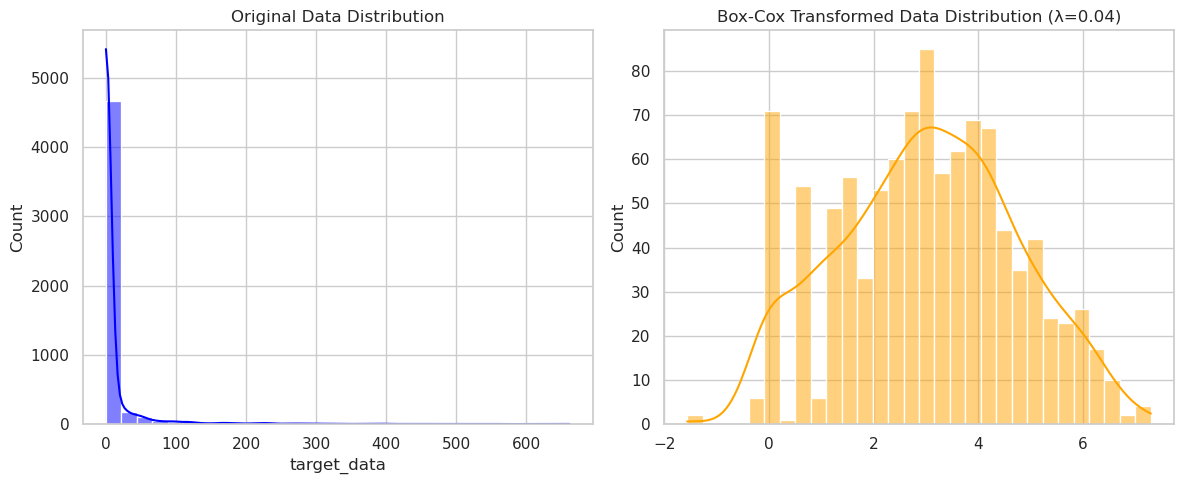

: 

In [ ]:
# compute the cox box value lambda
import scipy.stats as stats
data_egg_plus_one = data_egg[data_egg["target_data"] > 0]["target_data"]

# Compute Box-Cox transform and the best lambda
y_transformed, lambda_opt = stats.boxcox(data_egg_plus_one)
print(f"Optimal Box-Cox lambda: {lambda_opt}")

# the two distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data_egg["target_data"], bins=30, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Original Data Distribution")
sns.histplot(y_transformed, bins=30, kde=True, ax=ax[1], color='orange')
ax[1].set_title(f"Box-Cox Transformed Data Distribution (λ={lambda_opt:.2f})")
plt.tight_layout()
fig.savefig(f"./BoxCox_transformation.pdf")
plt.show()
